# Assignment 2 – Question 5: McCulloch-Pitts (MP) Neuron — Cinema Preference System

## MP Neuron Model (McCulloch & Pitts, 1943)

The MP neuron has **no weights**. Each input $x_i$ is either **excitatory** or **inhibitory**.

$$y = 0 \quad \text{if any inhibitory input is active (= 1)}$$

Otherwise, aggregate via:
$$g(x_1, x_2, \ldots, x_n) = \sum_{i=1}^{n} x_i \quad \text{(excitatory inputs only)}$$

Then apply the step (thresholding) activation function $f$:
$$y = f(g(\mathbf{x})) = \begin{cases} 1 & \text{if } g(\mathbf{x}) \geq \theta \\ 0 & \text{if } g(\mathbf{x}) < \theta \end{cases}$$

$\theta$ is the **thresholding parameter**.

---

## Problem Statement

| Ticket Price | Total Seats | Multiplex | Reachability | Preferred |
|---|---|---|---|---|
| 700 | 800 | No | Easy | Yes |
| 250 | 1500 | Yes | Difficult | No |
| 400 | 500 | Yes | Easy | Yes |
| 550 | 2000 | No | Difficult | Yes |

### Binarisation Rules — x₁: **0 if Price ≤ 300, else 1**

| Feature | Rule | → 1 | → 0 |
|---|---|---|---|
| x₁ – Ticket Price | **> 300** | > 300 | ≤ 300 |
| x₂ – Total Seats  | ≥ 1000 | ≥ 1000 | < 1000 |
| x₃ – Multiplex    | Yes/No | Yes | No |
| x₄ – Reachability | Easy/Difficult | Easy | Difficult |
| y  – Preferred    | Yes/No | Yes | No |

In [14]:
import numpy as np
import pandas as pd

# ── Raw dataset ───────────────────────────────────────────────────────────────
raw = {
    'Ticket_Price': [700, 250, 400, 550],
    'Total_Seats':  [800, 1500, 500, 2000],
    'Multiplex':    ['No',  'Yes', 'Yes', 'No'],
    'Reachability': ['Easy', 'Difficult', 'Easy', 'Difficult'],
    'Preferred':    ['Yes', 'No', 'Yes', 'Yes'],
}
df_raw = pd.DataFrame(raw)

# ── Binarise  (x1: 0 if Price <= 300, else 1) ────────────────────────────────
df = pd.DataFrame()
df['x1 (Price>300)']   = (df_raw['Ticket_Price'] > 300).astype(int)
df['x2 (Seats>=1000)'] = (df_raw['Total_Seats']  >= 1000).astype(int)
df['x3 (Multiplex)']   = (df_raw['Multiplex']    == 'Yes').astype(int)
df['x4 (Reachability)']= (df_raw['Reachability'] == 'Easy').astype(int)
df['y (Preferred)']    = (df_raw['Preferred']    == 'Yes').astype(int)

print("=" * 65)
print("   Binary Input-Output Table  [x1: 0 if Price<=300, else 1]")
print("=" * 65)
print(df.to_string(index=False))
print("=" * 65)

X_all = df[['x1 (Price>300)', 'x2 (Seats>=1000)',
            'x3 (Multiplex)', 'x4 (Reachability)']].values
y     = df['y (Preferred)'].values
g_all = X_all.sum(axis=1)

print(f"\ng(x) with ALL 4 excitatory inputs: {g_all.tolist()}")
y_S2 = g_all[1]
others = [g_all[i] for i in [0, 2, 3]]
print(f"  g(S2 [No]) = {y_S2},  g(Yes samples) = {others}")
if y_S2 in others:
    print("  g(S2) overlaps with a Yes-class sample => all-4-excitatory won't work.")
else:
    print("  g values all differ => a threshold might work with all 4.")
print()


   Binary Input-Output Table  [x1: 0 if Price<=300, else 1]
 x1 (Price>300)  x2 (Seats>=1000)  x3 (Multiplex)  x4 (Reachability)  y (Preferred)
              1                 0               0                  1              1
              0                 1               1                  0              0
              1                 0               1                  1              1
              1                 1               0                  0              1

g(x) with ALL 4 excitatory inputs: [2, 2, 3, 2]
  g(S2 [No]) = 2,  g(Yes samples) = [np.int64(2), np.int64(3), np.int64(2)]
  g(S2) overlaps with a Yes-class sample => all-4-excitatory won't work.



## Selecting Excitatory Inputs and Threshold θ

### Binary table with new x₁ rule (> 300 → 1)

| Sample | x₁ (Price>300) | x₂ | x₃ | x₄ | y |
|---|:---:|:---:|:---:|:---:|:---:|
| S1 (700, Easy)  | 1 | 0 | 0 | 1 | 1 |
| S2 (250, Diff)  | **0** | 1 | 1 | 0 | **0** |
| S3 (400, Easy)  | 1 | 0 | 1 | 1 | 1 |
| S4 (550, Diff)  | 1 | 1 | 0 | 0 | 1 |

### Analysis

With this threshold (> 300), **only S2 has x₁ = 0** because 250 is the only price ≤ 300.  
All three "Yes" samples have Price > 300, giving x₁ = 1.

This means **x₁ alone** can already separate the classes — fire if x₁ ≥ 1 (θ = 1).  
Adding x₄ as a second excitatory input ({x₁, x₄}, θ = 1) also works.

| Input | Role |
|---|---|
| x₁ (Price > 300) | **Excitatory** |
| x₂ (Seats ≥ 1000) | Not connected |
| x₃ (Multiplex) | Not connected |
| x₄ (Reachability = Easy) | **Excitatory** (optional — also valid alone with x₁) |

$$g(\mathbf{x}) = x_1 + x_4 \qquad \theta = 1$$

In [15]:
# ── MP Neuron (no weights): excitatory inputs x1, x4 ─────────────────────────
theta = 1

X_exc = df[['x1 (Price>300)', 'x4 (Reachability)']].values
g     = X_exc.sum(axis=1)
y_hat = (g >= theta).astype(int)

print("=" * 72)
print(f"MP Neuron (no weights)  |  Excitatory: x1, x4  |  theta = {theta}")
print("Rule: x1 = 0 if Price <= 300, else 1")
print("=" * 72)
print(f"{'Sample':<8}{'x1':<8}{'x2':<6}{'x3':<6}{'x4':<6}{'g=x1+x4':<12}{'y_hat':<8}{'y':<8}{'OK?'}")
print("-" * 72)

for i in range(len(y)):
    row = df.iloc[i]
    ok  = "OK" if y_hat[i] == y[i] else "WRONG"
    print(f"  S{i+1:<5}"
          f"{int(row['x1 (Price>300)']):<8}"
          f"{int(row['x2 (Seats>=1000)']):<6}"
          f"{int(row['x3 (Multiplex)']):<6}"
          f"{int(row['x4 (Reachability)']):<6}"
          f"{g[i]:<12}"
          f"{y_hat[i]:<8}"
          f"{y[i]:<8}"
          f"{ok}")

print("=" * 72)
accuracy = (y_hat == y).mean() * 100
all_ok   = np.array_equal(y_hat, y)
print(f"\nAccuracy : {accuracy:.1f}%")
print(f"All samples correctly classified : {all_ok}")


MP Neuron (no weights)  |  Excitatory: x1, x4  |  theta = 1
Rule: x1 = 0 if Price <= 300, else 1
Sample  x1      x2    x3    x4    g=x1+x4     y_hat   y       OK?
------------------------------------------------------------------------
  S1    1       0     0     1     2           1       1       OK
  S2    0       1     1     0     0           0       0       OK
  S3    1       0     1     1     2           1       1       OK
  S4    1       1     0     0     1           1       1       OK

Accuracy : 100.0%
All samples correctly classified : True


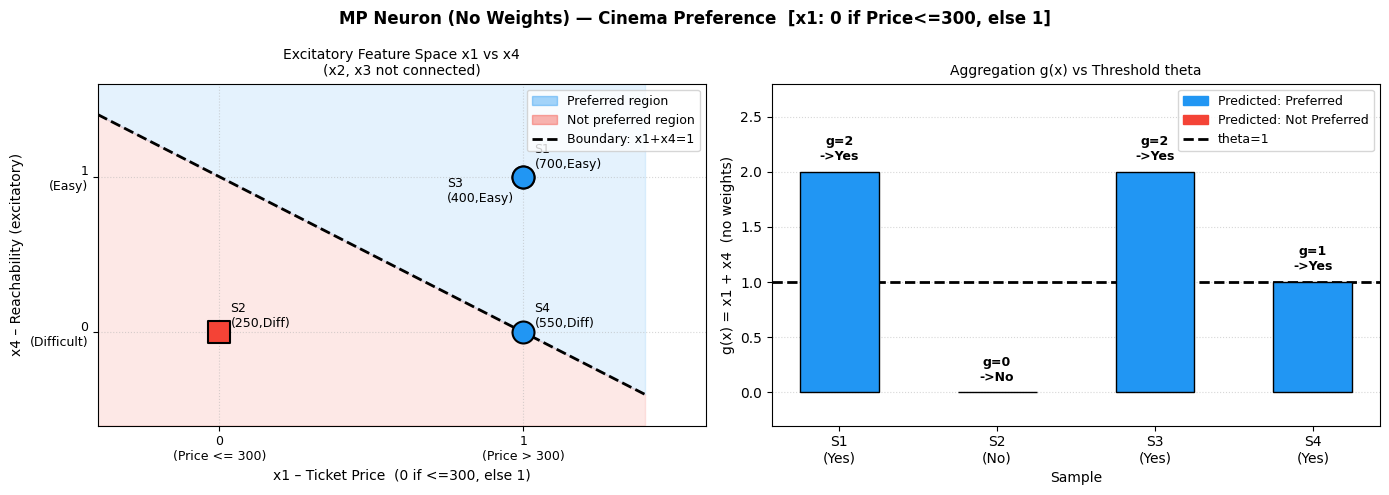

Figure saved as mp_neuron_cinema_price300.png


In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("MP Neuron (No Weights) — Cinema Preference  [x1: 0 if Price<=300, else 1]",
             fontsize=12, fontweight='bold')

colors  = {1: '#2196F3', 0: '#F44336'}
markers = {1: 'o', 0: 's'}
sample_labels  = ['S1\n(700,Easy)', 'S2\n(250,Diff)', 'S3\n(400,Easy)', 'S4\n(550,Diff)']
label_offsets  = [(8, 6), (8, 4), (-55, -18), (8, 4)]  # S3 offset left-down to avoid S1 overlap

# ── Left: excitatory feature space x1 vs x4 ──────────────────────────────────
ax1 = axes[0]
for i in range(4):
    ax1.scatter(X_exc[i, 0], X_exc[i, 1],
                c=colors[y[i]], marker=markers[y[i]],
                s=250, zorder=5, edgecolors='black', linewidths=1.5)
    ax1.annotate(sample_labels[i],
                 (X_exc[i, 0], X_exc[i, 1]),
                 textcoords="offset points",
                 xytext=label_offsets[i], fontsize=9)

x1_vals = np.linspace(-0.4, 1.4, 200)
x4_bnd  = theta - x1_vals
ax1.fill_between(x1_vals, x4_bnd, 1.6,  alpha=0.12, color='#2196F3')
ax1.fill_between(x1_vals, -0.6, x4_bnd, alpha=0.12, color='#F44336')
ax1.plot(x1_vals, x4_bnd, 'k--', lw=2, label=f'x1+x4={theta}')

ax1.set_xlim(-0.4, 1.6); ax1.set_ylim(-0.6, 1.6)
ax1.set_xticks([0, 1]); ax1.set_yticks([0, 1])
ax1.set_xticklabels(['0\n(Price <= 300)', '1\n(Price > 300)'], fontsize=9)
ax1.set_yticklabels(['0\n(Difficult)', '1\n(Easy)'], fontsize=9)
ax1.set_xlabel('x1 – Ticket Price  (0 if <=300, else 1)', fontsize=10)
ax1.set_ylabel('x4 – Reachability (excitatory)', fontsize=10)
ax1.set_title('Excitatory Feature Space x1 vs x4\n(x2, x3 not connected)', fontsize=10)
ax1.legend(handles=[
    mpatches.Patch(color='#2196F3', alpha=0.4, label='Preferred region'),
    mpatches.Patch(color='#F44336', alpha=0.4, label='Not preferred region'),
    Line2D([0], [0], color='k', ls='--', lw=2, label=f'Boundary: x1+x4={theta}'),
], fontsize=9, loc='upper right')
ax1.grid(True, ls=':', alpha=0.5)

# ── Right: g(x) bars per sample ──────────────────────────────────────────────
ax2 = axes[1]
bar_cols = [colors[y[i]] for i in range(4)]
bars = ax2.bar(range(1, 5), g, color=bar_cols, edgecolor='black', width=0.5, zorder=3)
ax2.axhline(y=theta, color='black', ls='--', lw=2, label=f'theta = {theta}')

ax2.set_xticks(range(1, 5))
ax2.set_xticklabels([f'S{i+1}\n({"Yes" if y[i] else "No"})' for i in range(4)])
ax2.set_xlabel('Sample', fontsize=10)
ax2.set_ylabel('g(x) = x1 + x4  (no weights)', fontsize=10)
ax2.set_title('Aggregation g(x) vs Threshold theta', fontsize=10)
ax2.set_ylim(-0.3, 2.8)
ax2.grid(True, axis='y', ls=':', alpha=0.5)

for bar, gi, yh in zip(bars, g, y_hat):
    ax2.text(bar.get_x() + bar.get_width()/2., gi + 0.08,
             f"g={gi}\n->{'Yes' if yh else 'No'}",
             ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.legend(handles=[
    mpatches.Patch(color='#2196F3', label='Predicted: Preferred'),
    mpatches.Patch(color='#F44336', label='Predicted: Not Preferred'),
    Line2D([0], [0], color='k', ls='--', lw=2, label=f'theta={theta}'),
], fontsize=9)

plt.tight_layout()
plt.savefig('mp_neuron_cinema_price300.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as mp_neuron_cinema_price300.png")


In [18]:
# ── Brute-force: all excitatory-input subsets × all theta ────────────────────
from itertools import combinations

feature_cols = ['x1 (Price>300)', 'x2 (Seats>=1000)', 'x3 (Multiplex)', 'x4 (Reachability)']
X_full = df[feature_cols].values
fnames = ['x1', 'x2', 'x3', 'x4']

valid = []
for r in range(1, 5):
    for subset in combinations(range(4), r):
        X_sub = X_full[:, list(subset)]
        g_sub = X_sub.sum(axis=1)
        for th in range(0, 5):
            preds = (g_sub >= th).astype(int)
            if np.array_equal(preds, y):
                valid.append(([fnames[j] for j in subset], th))

print(f"Valid (excitatory-subset, theta) combinations found: {len(valid)}\n")
if valid:
    print(f"{'Excitatory Inputs':<30} {'theta':>6}")
    print("-" * 38)
    for exc, th in valid:
        print(f"  {str(exc):<28} {th:>6}")
    print("\n=> The problem IS linearly separable with an MP neuron.")
else:
    print("=> NO valid configuration found.")
    print("   The problem is NOT linearly separable under this MP neuron formulation.")


Valid (excitatory-subset, theta) combinations found: 3

Excitatory Inputs               theta
--------------------------------------
  ['x1']                            1
  ['x1', 'x4']                      1
  ['x1', 'x2', 'x4']                2

=> The problem IS linearly separable with an MP neuron.


## Summary

### 1. Binary Input–Output Table (x₁: 0 if Price ≤ 300, else 1)

| Sample | x₁ (Price>300) | x₂ (Seats≥1000) | x₃ (Multiplex) | x₄ (Reach=Easy) | y |
|---|:---:|:---:|:---:|:---:|:---:|
| S1 (700, 800, No, Easy)       | 1 | 0 | 0 | 1 | **1** |
| S2 (250, 1500, Yes, Difficult)| **0** | 1 | 1 | 0 | **0** |
| S3 (400, 500, Yes, Easy)      | 1 | 0 | 1 | 1 | **1** |
| S4 (550, 2000, No, Difficult) | 1 | 1 | 0 | 0 | **1** |

Key change vs. original (≥ 500): **S3 now has x₁ = 1** (400 > 300), whereas before it had x₁ = 0.

---

### 2. MP Neuron Verification

$$g(\mathbf{x}) = x_1 + x_4 \qquad \theta = 1$$

| Sample | g = x₁ + x₄ | g ≥ θ? | ŷ | y | Correct? |
|---|:---:|:---:|:---:|:---:|:---:|
| S1 | 1+1 = 2 | Yes | 1 | 1 | ✓ |
| S2 | 0+0 = 0 | No  | 0 | 0 | ✓ |
| S3 | 1+1 = 2 | Yes | 1 | 1 | ✓ |
| S4 | 1+0 = 1 | Yes | 1 | 1 | ✓ |

**Accuracy = 100% — all samples correctly classified.**

---

### 3. Linear Separability — More Solutions Than Before

The brute-force search found **3 valid configurations** (vs. 1 with the original ≥ 500 rule):

| Excitatory Inputs | θ | Why it works |
|---|:---:|---|
| {x₁} | 1 | S2 is the **only** sample with x₁ = 0; x₁ alone is sufficient! |
| {x₁, x₄} | 1 | Classic pair; fires if either is active |
| {x₁, x₂, x₄} | 2 | Requires at least 2 of the three active features |

With Price > 300, **x₁ alone perfectly separates** the data — S2 is the sole sample with Price ≤ 300.  
x₄ is no longer strictly necessary (though it remains a valid addition).

---

### 4. Comparison Across All Three Rules

| Rule | x₁ = [S1,S2,S3,S4] | Separable? | Valid configs | Note |
|---|:---:|:---:|:---:|---|
| Price ≥ 500   | [1, 0, 0, 1] | Yes | 1 | x₁ alone not enough (S3=0=Yes) |
| Price < 500   | [0, 1, 1, 0] | No  | 0 | S4 structurally trapped |
| **Price > 300** | **[1, 0, 1, 1]** | **Yes** | **3** | x₁ alone sufficient; S2 uniquely 0 |